In [ ]:
import numpy as np
import nibabel as nib
import tempfile
import os
import tarfile 
import matplotlib.pyplot as plt
import random

In [ ]:
path = "D:/marchine_learning/Projet/Segmentation/BraTS2021_Training_Data.tar"
random.seed(42)
output_dir = "D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/" 
os.makedirs(output_dir, exist_ok=True)

In [4]:
# Dictionnaire patient → Lister tous les patients dans le
patients = {}
volumes = {}

# --------------------------------------------------------- #
# 1) Lister les patients et leurs fichiers 
#  ---------------------------------------------------------
with tarfile.open(path, "r") as tar:
    for member in tar.getmembers():
        if member.name.endswith(".nii.gz"):
            parts = member.name.split("/")
            if len(parts) < 3:
                continue
            id_patient = parts[1]
            if not(id_patient in patients):
                patients[id_patient] = []
            patients[id_patient].append(member.name)

selected_patients = random.sample(list(patients.keys()), 300)

# --------------------------------------------------------- 
#  2) Calculer le volume tumoral pour chaque patient 
#  ---------------------------------------------------------
with tarfile.open(path, "r") as tar:
    for patient in selected_patients:
        
        if not ("_seg" in patients[patient][1]): # ex: BraTS2021_00000_seg.nii.gz
                continue 
        f = tar.extractfile(patients[patient][1])     
        # fichier temporaire 
        with tempfile.NamedTemporaryFile(delete=False, suffix=".nii.gz") as tmp: 
            tmp.write(f.read()) 
            tmp_path = tmp.name 

        seg = nib.load(tmp_path).get_fdata() 
        os.remove(tmp_path) 
        
        # Volume tumoral = voxels non nuls 
        tumor_volume = np.sum(seg > 0) 
        volumes[patient] = tumor_volume


In [5]:

# ---------------------------------------------------------
# 3) Sélectionner les 35 plus gros + 15 plus petits volumes
# ---------------------------------------------------------
sorted_patients = sorted(volumes.items(), key=lambda x: x[1], reverse=True)

top_35 = sorted_patients[:35]
bottom_15 = sorted_patients[-15:]

selected = top_35 + bottom_15
selected_patients = [p for p, v in selected]

print("Patients sélectionnés :", len(selected_patients))

# ---------------------------------------------------------
# 4) Sauvegarder chaque patient en NPZ
# ---------------------------------------------------------
with tarfile.open(path, "r") as tar:
    for patient in selected_patients:

        data = {'flair': None, 't1': None, 't1ce': None, 't2': None, 'seg': None}

        for member in patients[patient]:
            f = tar.extractfile(member)

            with tempfile.NamedTemporaryFile(delete=False, suffix=".nii.gz") as tmp:
                tmp.write(f.read())
                tmp_path = tmp.name

            img = nib.load(tmp_path).get_fdata()
            os.remove(tmp_path)

            filename = os.path.basename(member)
            modality = filename.split("_")[-1].replace(".nii.gz", "")

            data[modality] = img

        # nom du fichier NPZ avec volume
        vol = volumes[patient]
        save_path = os.path.join(output_dir, f"{patient}_vol_{vol}.npz")

        #np.savez_compressed(save_path,
        #                    flair=data['flair'],
        #                    t1=data['t1'],
        #                    t1ce=data['t1ce'],
        #                    t2=data['t2'],
        #                    seg=data['seg'],
        #                    volume=vol)

        print("Saved:", save_path)


Patients sélectionnés : 50
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01554_vol_242338.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_00095_vol_236428.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01528_vol_232098.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01079_vol_226241.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_00449_vol_220576.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01496_vol_218263.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01416_vol_217356.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_00714_vol_212918.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01523_vol_212186.npz
Saved: D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_01045_vol_211084.npz
Saved: D:/mar

Image shape: (240, 240, 155)
Volume tumoral: 185011


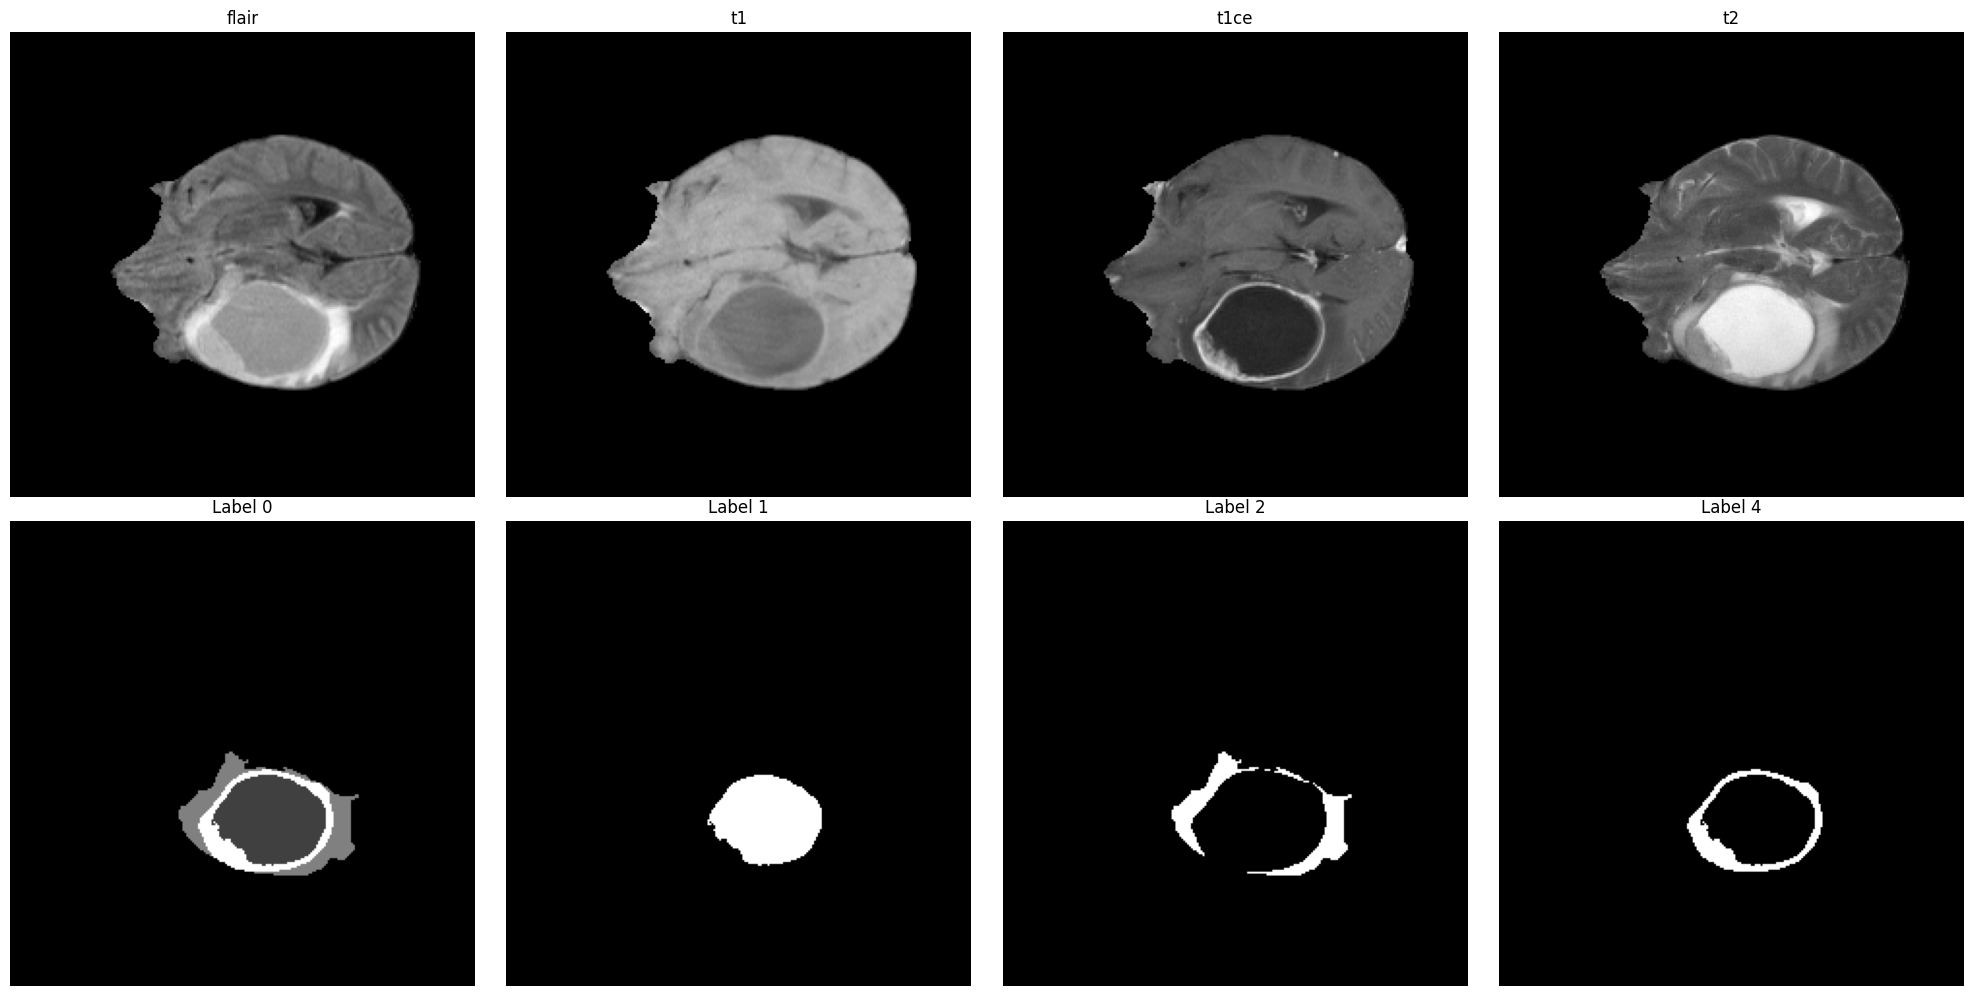

In [12]:
files_npz = os.listdir(output_dir)
files_npz = [f for f in files_npz if f.endswith(".npz")]
idx_rd = np.random.randint(len(files_npz))
data = np.load(os.path.join(output_dir, files_npz[48]))

print("Image shape:", data['seg'].shape)
print("Volume tumoral:", data["volume"])

# Modalités (tout sauf volume et seg)
modalities = [k for k in data.files if k not in ['volume', 'seg']]
labels = [0, 1, 2, 4]
total = len(modalities) + len(labels)

# Grille : 2 lignes, colonnes = total/2 arrondi
cols = int(np.ceil(total / 2))
rows = 2
plt.figure(figsize=(5 * cols, 10))
i = 1

# --- Affichage des modalités ---
for key in modalities:
    plt.subplot(rows, cols, i)
    plt.imshow(data[key][:, :, 62], cmap='gray')
    plt.title(key)
    plt.axis("off")
    i += 1

# --- Affichage des labels ---
for j in labels:
    plt.subplot(rows, cols, i)
    if j > 0:
        plt.imshow(data['seg'][:, :, 62] == j, cmap='gray')
    else:
        plt.imshow(data['seg'][:, :, 62], cmap='gray')
    plt.title(f"Label {j}")
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import os
import pandas as pd

# Définition des intervalles
intervals = [
    (0, 31),
    (32, 62),
    (63, 93),
    (94, 124),
    (125, 154)
]

rows = []  # stockage des résultats

for file_npz in files_npz:
    break
    data = np.load(os.path.join(output_dir, file_npz))
    seg = data["seg"]

    for start, end in intervals:
        # Calcul du volume tumoral pour chaque slice de l'intervalle
        volumes = [np.sum(seg[:, :, i] > 0) for i in range(start, end + 1)]

        # Trouver le max et son index global
        max_volume = max(volumes)
        max_index = start + volumes.index(max_volume)

        # Ajouter une ligne au tableau
        rows.append({
            "file": file_npz,
            "interval": f"{start}-{end}",
            "max_index": max_index,
            "max_volume": max_volume
        })

# Création du DataFrame
df = pd.DataFrame(rows)

# Sauvegarde en CSV
#df.to_csv("intervals_info.csv", index=False)

df.head(6)


,file,interval,max_index,max_volume
0,BraTS2021_00147_vol_175302.npz,0-31,0,0
1,BraTS2021_00147_vol_175302.npz,32-62,62,2275
2,BraTS2021_00147_vol_175302.npz,63-93,83,3361
3,BraTS2021_00147_vol_175302.npz,94-124,94,2967
4,BraTS2021_00147_vol_175302.npz,125-154,125,287
5,BraTS2021_00266_vol_175363.npz,0-31,0,0


In [18]:
df_mean = df.groupby("interval")[["max_index", 'max_volume']].mean().reset_index()
df_mean

,interval,max_index,max_volume
0,0-31,7.32,85.84
1,125-154,125.00,360.46
2,32-62,57.70,1910.46
3,63-93,77.46,3349.58
4,94-124,94.90,2441.92


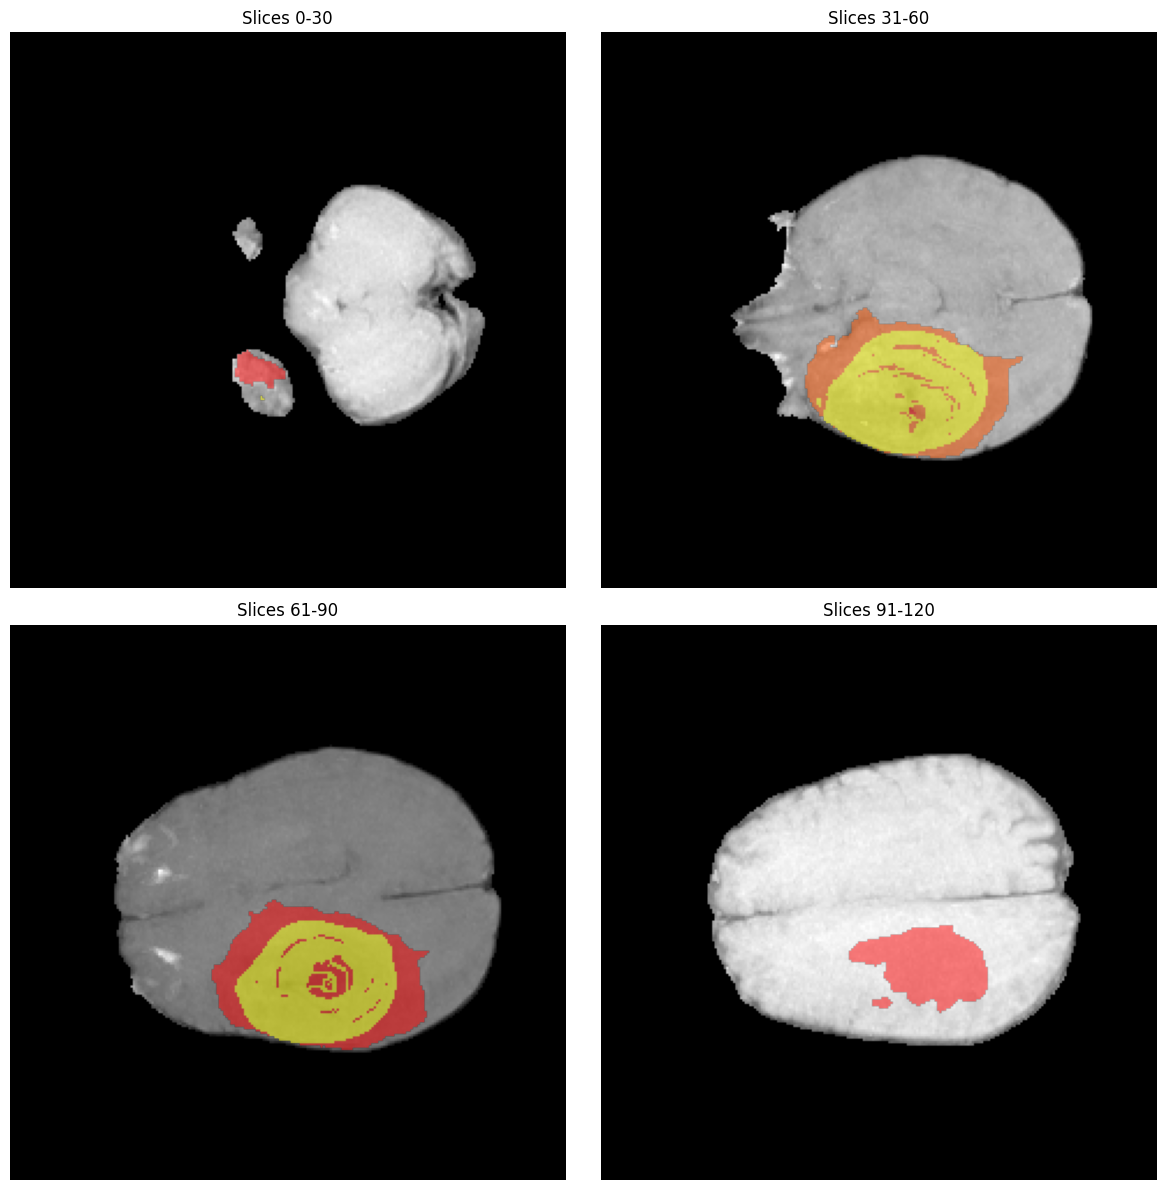

In [13]:
import numpy as np
import matplotlib.pyplot as plt

img = data['t1']      # ou flair, t2, t1ce
seg = data['seg']

intervals = [
    (0, 30),
    (31, 60),
    (61, 90),
    (91, 120)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (start, end) in zip(axes.flatten(), intervals):
    # On prend une projection max pour visualiser le volume
    img_sub = img[:, :, start:end+1]
    seg_sub = seg[:, :, start:end+1]

    # Projection maximale (vue 3D compressée)
    proj_img = np.max(img_sub, axis=2)
    proj_seg = np.max(seg_sub, axis=2)

    ax.imshow(proj_img, cmap='gray')
    ax.imshow(np.ma.masked_where(proj_seg == 0, proj_seg), cmap='autumn', alpha=0.5)

    ax.set_title(f"Slices {start}-{end}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import napari
import numpy as np

image = data['t1']          # ou autre modalité
mask = data['seg']
mask = mask.astype(np.int32)

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, name='IRM')
viewer.add_labels(mask, name='Segmentation')

napari.run()

In [19]:
import pyvista as pv

mask = data['seg'].astype(np.uint8) 
mesh = pv.wrap(mask)
plotter = pv.Plotter()
plotter.add_mesh(mesh)
plotter.show()


Widget(value='<iframe src="http://localhost:50963/index.html?ui=P_0x168e5e04aa0_0&reconnect=auto" class="pyvis…

In [8]:
import pyvista as pv

plotter = pv.Plotter()

image = data['t1']          # volume IRM
mask = data['seg'].astype(np.uint8)  # masque binaire

# --- Volume IRM ---
plotter.add_volume(
    pv.wrap(image),
    opacity=0.2,
    cmap="gray",
    shade=False
)

# --- Surface de la tumeur ---
# Important : pour un masque binaire, l’isovaleur doit être 0.5
tumor_surface = pv.wrap(mask).contour(isosurfaces=[0.5])

plotter.add_mesh(
    tumor_surface,
    color="red",
    opacity=0.7,
    smooth_shading=True
)

plotter.show(jupyter_backend='trame')


Widget(value='<iframe src="http://localhost:56865/index.html?ui=P_0x218917e7c80_3&reconnect=auto" class="pyvis…

In [ ]:
import vtk
from vtk.util import numpy_support
import numpy as np

tumor = (data['seg'] > 0).astype(np.uint8)

# Conversion NumPy → VTK
vtk_data = numpy_support.numpy_to_vtk(tumor.flatten(), deep=True)
image = vtk.vtkImageData()
image.SetDimensions(tumor.shape)
image.GetPointData().SetScalars(vtk_data)

# Volume rendering
mapper = vtk.vtkSmartVolumeMapper()
mapper.SetInputData(image)

volume = vtk.vtkVolume()
volume.SetMapper(mapper)

renderer = vtk.vtkRenderer()
renderer.AddVolume(volume)

window = vtk.vtkRenderWindow()
window.AddRenderer(renderer)

interactor = vtk.vtkRenderWindowInteractor()
interactor.SetRenderWindow(window)

window.Render()
interactor.Start()
